In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.src.layers import MaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, LSTM, TimeDistributed, Conv1D
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from math import sqrt
import matplotlib.pyplot as plt

In [2]:
np.random.seed(7)
tf.random.set_seed(7)

In [3]:
csv_path = "/Parte_2/TensorFlow/demand-forecasting-kernels-only/train.csv"
train = pd.read_csv(csv_path, parse_dates=['date'])

#Filtro para una serie | ID de la tienda y ID del producto
train = train.query("store == 1 and item == 1").copy()
train = train.sort_values("date")
print(train.head())
print(len(train))

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10
1826


In [4]:
def make_supervised_windows(series: np.ndarray, window_size: int, lag: int):
    X, y = [], []
    for i in range(window_size, len(series)-lag):
        X.append(series[i-window_size:i+1])
        y.append(series[i+lag]) #Todavía nos sirven los datos de lso días anteriores para hacer predicciones
    return np.array(X), np.array(y)

In [5]:
window = 29
lag = 1

X,y = make_supervised_windows(train['sales'].values, window, lag)
print("X", X.shape, "y", y.shape)

X (1796, 30) y (1796,)


In [6]:
# División temporal y escalado
cut = int(len(X)*0.8)
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]

scaler_x = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.reshape(-1,1))

X_train_s = scaler_x.transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.transform(y_train.reshape(-1,1)).ravel() #Cuando tenemos matriz y lo convertimos en un vector "aplanado"
y_test_s = scaler_y.transform(y_test.reshape(-1,1)).ravel()

print("X_train shape", X_train_s.shape, "y_train shape", y_train_s.shape)

X_train shape (1436, 30) y_train shape (1436,)


In [7]:
X_train_3d = X_train_s.reshape(len(X_train_s), window+1, 1)
X_test_3d = X_test_s.reshape(len(X_test_s), window+1, 1)

print("Train 3d:", X_train_3d.shape, "Test 3d:", X_test_3d.shape)

Train 3d: (1436, 30, 1) Test 3d: (360, 30, 1)


In [8]:
#CNN 1D
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation="relu", input_shape=(window+1, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    #Entran dos capas con diferente cantidad de neuronas.
    Dense(32, activation="relu"),
    Dense(1)
])

model_cnn.compile(optimizer="adam", loss="mse")
model_cnn.summary()

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,529 (56.75 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_cnn = model_cnn.fit(X_train_3d, y_train_s, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.6688 
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5665
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5410 
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - loss: 0.5224
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5089
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4959
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4850
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.4771
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - loss: 0.4656
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.4552
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 0.4466
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - loss: 0.4374
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: 0.4281
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - loss: 0.4198
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - loss: 0.41

In [10]:
#Predictions
pred_cnn_s = model_cnn.predict(X_test_3d).ravel()
pred_cnn = scaler_y.inverse_transform(pred_cnn_s.reshape(-1,1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_cnn)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RMSE:  6.746697359630946


# LSTM

In [11]:
model_lstm = Sequential([
    LSTM(units=32, activation="tanh", input_shape=(window+1, 1)),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_lstm = model_lstm.fit(X_train_3d, y_train_s, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7948
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6694
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6666
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6647
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6632
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6617
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6604
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6591
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6578
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6565
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6551
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6536
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6520
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6501
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6480
Epoch 16/50
45/45 ━

In [13]:
#Predictions
pred_lstm_s = model_lstm.predict(X_test_3d).ravel()
pred_lstm = scaler_y.inverse_transform(pred_lstm_s.reshape(-1,1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RMSE:  5.405658314690778


# CCN + LSTM

CNN se encarga de sacar los patrones

Para LSTM se dedique a encontrar relaciones temporales

In [14]:
subseq = 5
assert (window+1) % subseq == 0, "Windows must be divisible by subseq"
steps_per_subseq = (window+1)//subseq

Xtr4 = X_train_3d.reshape((len(X_train_3d), subseq, steps_per_subseq, 1))
Xva4 = X_test_3d.reshape((len(X_test_3d), subseq, steps_per_subseq, 1))

model_cnn_lstm = Sequential([
    TimeDistributed(Conv1D(filters=32, kernel_size=3, activation="relu"), input_shape=(subseq, steps_per_subseq, 1)),
    TimeDistributed(MaxPooling1D(pool_size=2)),
    TimeDistributed(Flatten()),
    LSTM(units=32, activation="tanh"),
    Dense(1)
])

model_cnn_lstm.compile(optimizer="adam", loss="mse")
model_cnn_lstm.summary()

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 4, 32)       │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 2, 32)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 64)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_cnn_lstm = model_cnn_lstm.fit(Xtr4, y_train_s, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7336
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6412
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6203
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6102
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6027
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5955
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5885
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5817
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5751
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5691
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5635
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5585
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5538
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5493
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5449
Epoch 16/50
45/45 ━

Xva4 are the test samples

In [16]:
pred_cnn_lstm_s = model_cnn_lstm.predict(Xva4).ravel()
pred_cnn_lstm = scaler_y.inverse_transform(pred_cnn_lstm_s.reshape(-1,1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_cnn_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RMSE:  5.436868389760161


In [17]:
rmse_cnn = sqrt(mean_squared_error(y_test, pred_cnn))
rmse_lstm = sqrt(mean_squared_error(y_test, pred_lstm))
rmse_cnn_lstm = sqrt(mean_squared_error(y_test, pred_cnn_lstm))

print("Summary RMSE")
print("CNN:", rmse_cnn)
print("LSTM:", rmse_lstm)
print("CNN + LSTM:", rmse_cnn_lstm)

Summary RMSE
CNN: 6.746697359630946
LSTM: 5.405658314690778
CNN + LSTM: 5.436868389760161


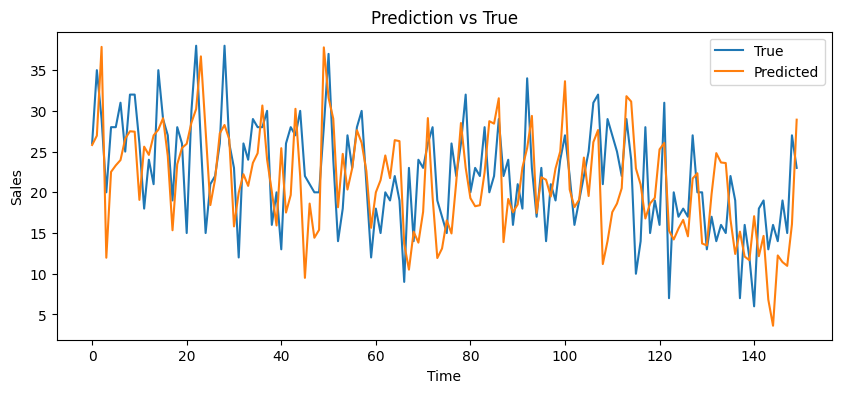

In [18]:
y_true = y_test
y_pred = pred_cnn

k = 150 if len(y_true) > 150 else len(y_true)

plt.figure(figsize=(10, 4))
plt.plot(y_true[-k:], label="True")
plt.plot(y_pred[-k:], label="Predicted")
plt.title("Prediction vs True")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

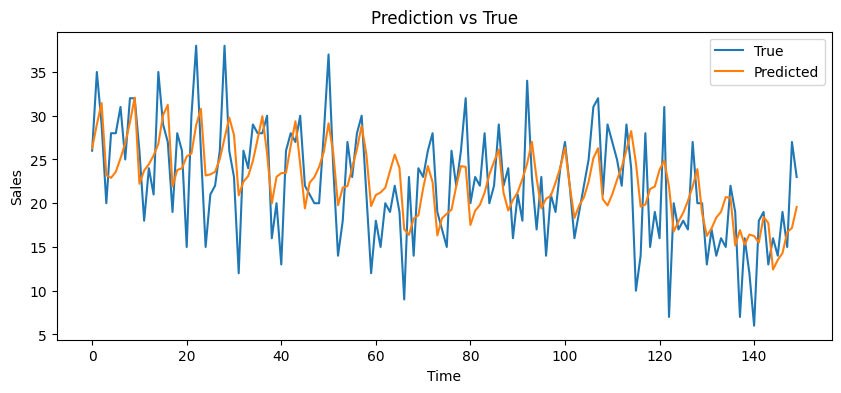

In [19]:
y_true = y_test
y_pred = pred_lstm

k = 150 if len(y_true) > 150 else len(y_true)

plt.figure(figsize=(10, 4))
plt.plot(y_true[-k:], label="True")
plt.plot(y_pred[-k:], label="Predicted")
plt.title("Prediction vs True")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

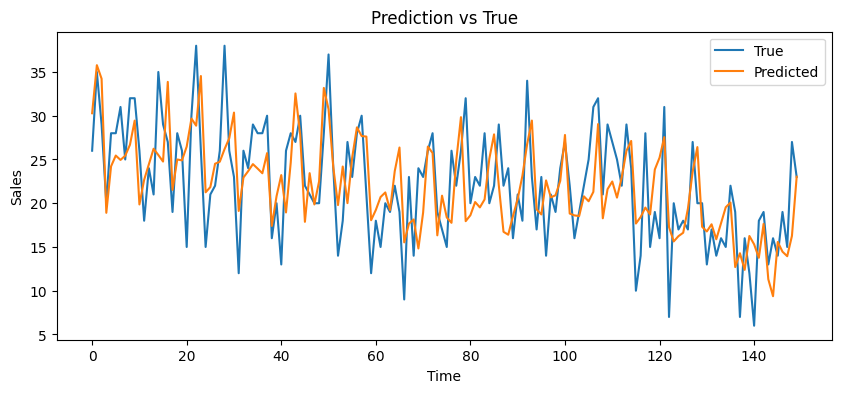

In [20]:
y_true = y_test
y_pred = pred_cnn_lstm

k = 150 if len(y_true) > 150 else len(y_true)

plt.figure(figsize=(10, 4))
plt.plot(y_true[-k:], label="True")
plt.plot(y_pred[-k:], label="Predicted")
plt.title("Prediction vs True")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()